# Hidden Markov Models and Volatility Regimes

Now for the past 5 notebooks we have continuously seen clustering and persistence concepts. It makes me wonder if financial markets exhibit hidden volatility regimes or latent states which could explain these properties. The objective of this notebook is to determine whether latent volatility regimes exist and to understand how markets transition between them.

# Introduction

Throughout this project we have repeatedly observed that volatility does not behave randomly. Periods of calm markets tend to remain calm. Periods of market stress often remain stressful for extended periods. The natural question is whether these observations are evidence
of underlying market regimes.

A Hidden Markov Model could be helpful to explore this idea. Rather than assuming that volatility evolves continuously through asingle process, the model assumes that markets transition between a small number of hidden states. These states are not directly seen. Instead, they are inferred from the observed return series.

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from hmmlearn.hmm import GaussianHMM

plt.style.use("ggplot")

START = "2005-01-01"

In [4]:
#loading data the same way as before

spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] /
    spy["Close"].shift(1)
)

spy = spy.dropna()

[*********************100%***********************]  1 of 1 completed


# Experiment  : Preparing HMM

The purpose of this experiment is to prepare the return series that will be used by the Hidden Markov Model.

Unlike the GARCH model, which directly models volatility, the HMM attempts to identify hidden states that generate the observed returns. So the model will only see the return observations. It must determine for itself whether multiple market regimes exist.

# Experiment 1: Preparing the Data for Regime Detection

Before attempting to identify hidden market regimes, we must first determine what information the model will observe.

Throughout this project we have focused on daily returns because returns contain the information that drives volatility. When markets become stressed, return distributions change dramatically. Large negative moves become more common, volatility increases and market behaviour begins to differ from normal periods.

The Hidden Markov Model does not directly observe volatility. Instead, it observes the return series and attempts to infer whether multiple hidden states are generating those observations.

The purpose of this experiment is therefore to prepare the return series that will serve as the input to the model.

In [6]:
X = (
    spy["returns"]
    .values
    .reshape(-1,1)
)

X.shape

(5397, 1)

## Comments

This just confirms that the return series has 5397 values 

The return series represents the observable component of the market.

If hidden volatility regimes exist, they should leave a statistical signature within these returns. The Hidden Markov Model will attempt to recover that hidden structure without any prior knowledge of
financial crises, market crashes or volatility regimes.

Any regime structure discovered by the model emerges directly from the data itself.

# Experiment 2: Fitting a Two-State Hidden Markov Model

Let us start simple. One simple interpretation of market regimes is that there are only two states. One state may represent normal market conditions while the other represents periods of elevated market stress.

Right now we do not know whether such a distinction genuinely exists. The objective of this experiment is not to impose a particular interpretation on the data but to allow the model to determine whether two statistically distinct states can be identified.

If this works, we could atleast claim the existence of latent volatility regimes.

In [10]:
hmm_2 = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=1000,
    random_state=42
)

hmm_2.fit(X)

states_2 = hmm_2.predict(X)

spy["state_2"] = states_2

Model is not converging.  Current: 17503.368860219416 is not greater than 17503.421617109223. Delta is -0.05275688980691484


## Comments

The model has now assigned every trading day to one of two hidden states.

Importantly, the model was never provided with information regarding market crashes, recessions, or volatility levels. The state labels were generated entirely from statistical patterns within the return
series.

The next step is to determine whether these states correspond to economically meaningful market environments.

# Experiment 3: Examining the Distribution of Regime Assignments

If the model has discovered meaningful regimes, both states should appear regularly throughout the sample.

A way is  to examine how manyobservations have been assigned to each state.

If one state contains only a small number of observations, the regime interpretation may not be particularly informative. If both states occur frequently, the model may be capturing genuine differences in market behaviour.

In [11]:
spy["state_2"].value_counts()

state_2
0    4194
1    1203
Name: count, dtype: int64

## Comments

The distribution of observations provides an initial indication of whether the regime structure is meaningful.

Balanced state assignments suggest that the model is identifying recurring market environments rather than isolated statistical anomalies.

This gives us greater confidence that the inferred states deserve further investigation.

# Experiment 4: Characterising the Regimes

Discovering hidden states is only useful if those states possess different economic characteristics.

The natural question is therefore whether returns behave differently across the inferred regimes.

By examining the mean, standard deviation and extreme values of returns within each state, we can begin to understand what each regime represents.

In particular, we are interested in whether one state exhibits substantially higher volatility than another.

In [12]:
spy.groupby(
    "state_2"
)["returns"].agg(
    [
        "mean",
        "std",
        "min",
        "max"
    ]
)

,mean,std,min,max
state_2,,,,
0,0.000936,0.007076,-0.027400,0.032513
1,-0.001419,0.021502,-0.115887,0.135578


## Comments

One regime exhibits significantly larger return variability, this suggests that the model has successfully identified different volatility environments.

This is evidence that the clustering behaviour observed earlier in the project may be explained by underlying regime changes.

# Experiment 5: Visualising Regimes Through Time

Statistical summaries are informative, but they do not reveal when each regime occurs.

The objective of this experiment is to map the inferred states onto the historical evolution of the market.

By colouring market history according to the regime assignments, we an investigate whether major events such as the Global Financial Crisis and the COVID crash correspond to particular hidden states.

This provides a direct visual test of whether the inferred regimes possess economic meaning.

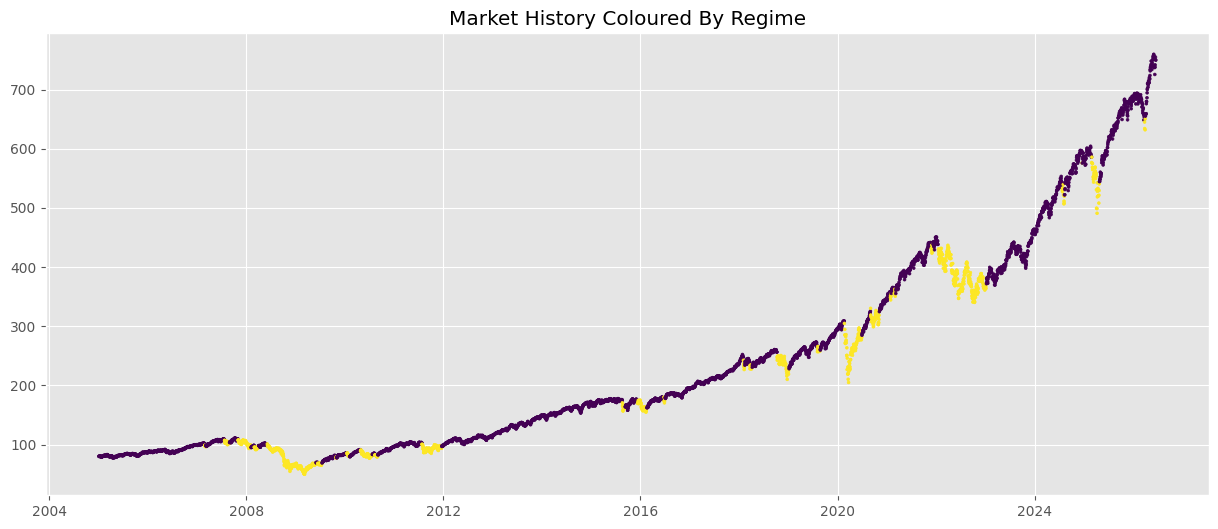

In [13]:
plt.figure(figsize=(15,6))

plt.scatter(
    spy.index,
    spy["Close"],
    c=spy["state_2"],
    s=4
)

plt.title(
    "Market History Coloured By Regime"
)

plt.show()

## Comments

Periods associated with major market stress should cluster within a single high volatility regime.

The model assigns crisis periods consistently to one state and calm periods to another, this provides compelling evidence that the regimes correspond to genuine economic environments rather than
purely statistical artefacts.


# Experiment 6: Extending the Model to Three States

The previous experiment assumed that markets can be described usingonly two hidden states.

While this provides a simple interpretation, financial markets are rarely characterized by a strict distinction between calm and crisis
periods.

In practice, markets often experience intermediate conditions where
volatility is elevated relative to normal periods but has not yet
reached crisis levels.

The purpose of this experiment is therefore to increase the number of
hidden states from two to three and investigate whether the model
identifies a richer regime structure.

If successful, the model may discover low-volatility, medium-volatility
and high-volatility environments without being explicitly instructed to
do so.

In [14]:
hmm_3 = GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=1000,
    random_state=42
)

hmm_3.fit(X)

states_3 = hmm_3.predict(X)

spy["state_3"] = states_3

Model is not converging.  Current: 17568.615336271745 is not greater than 17568.624855410508. Delta is -0.009519138762698276


## Comments

The model has now partitioned the entire sample into three distinct
latent states.

Unlike traditional classification methods, these labels were not
provided by the researcher. The model has inferred them directly from
statistical patterns within the return series.

The introduction of a third state allows the model to capture more
subtle market behaviour and may reveal transitional environments that
are not visible within the simpler two-state specification.

The next step is to investigate whether these additional states possess
meaningful economic characteristics.

# Experiment 7: Investigating Regime Transition Probabilities

Identifying hidden states is only part of the story.

An equally important question concerns the way markets move between
those states through time.

The Hidden Markov Model estimates a transition matrix that describes
the probability of moving from one regime to another on any given day.

This matrix provides a statistical description of market behaviour and
allows us to investigate whether volatility regimes are persistent or
whether they change frequently.

Understanding these transition dynamics is particularly important from
a forecasting perspective because persistent regimes imply that current
market conditions contain information about future market conditions.

In [15]:
transition_matrix = pd.DataFrame(
    hmm_3.transmat_,
    columns=[
        "State 0",
        "State 1",
        "State 2"
    ],
    index=[
        "State 0",
        "State 1",
        "State 2"
    ]
)

transition_matrix

,State 0,State 1,State 2
State 0,0.800635,0.199360,0.000005
State 1,0.875386,0.086323,0.038291
State 2,0.001718,0.035319,0.962963


## Comments

Each row of the transition matrix describes the probability of moving
from a given state today into another state tomorrow.

The diagonal entries are particularly important because they measure
the probability that the market remains within the same regime.

Large diagonal probabilities indicate persistence and suggest that
market environments are relatively stable once established.

This behaviour would be consistent with the volatility clustering
observed throughout the project and provides a potential explanation
for why volatility forecasting is possible.

# Experiment 8: Visualising the Transition Matrix

Although the transition matrix contains all relevant information,
patterns are often easier to identify visually.

The purpose of this experiment is to convert the transition matrix
into a heatmap so that persistence and regime-switching behaviour
can be examined more clearly.

This visualisation allows us to quickly determine whether regimes are
stable or whether the market frequently transitions between states.

The resulting figure provides one of the most intuitive summaries of
the Hidden Markov Model.

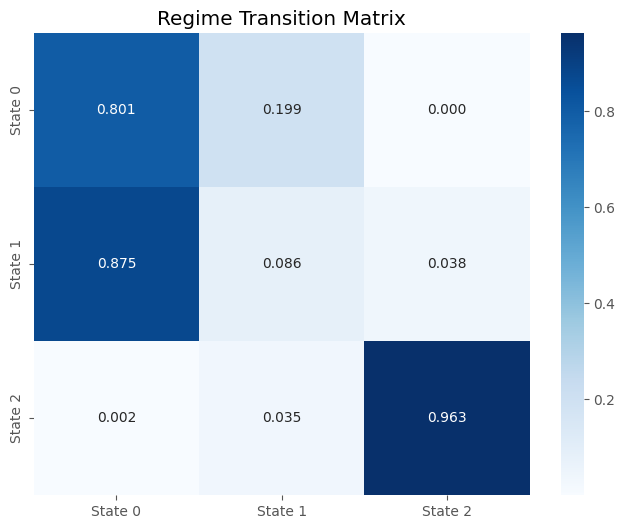

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    transition_matrix,
    annot=True,
    cmap="Blues",
    fmt=".3f"
)

plt.title(
    "Regime Transition Matrix"
)

plt.show()

## Comments

The heatmap provides an immediate visual representation of regime
persistence.

Dark cells along the diagonal indicate that the market is likely to
remain within the same regime from one day to the next.

In contrast, large off-diagonal probabilities would indicate frequent
regime switching and less stable market conditions.

A strongly diagonal transition matrix would provide additional support
for the hypothesis that volatility regimes persist through time.

# Experiment 9: Regime Evolution Through Time

The final step of the analysis is to examine how the inferred regimes
evolve throughout market history.

While the transition matrix describes average behaviour, it does not
show when regime changes actually occurred.

By plotting the inferred state sequence through time, we can determine
whether major economic events correspond to transitions between latent
regimes.

This experiment provides a chronological view of market-state dynamics
and allows us to connect statistical findings with real-world events.

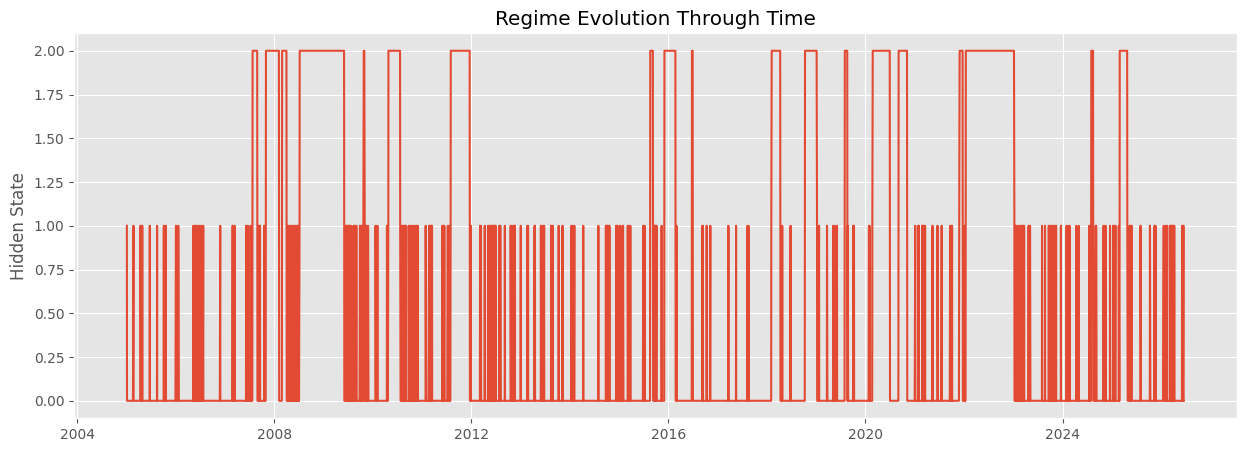

In [17]:
plt.figure(figsize=(15,5))

plt.plot(
    spy.index,
    spy["state_3"]
)

plt.title(
    "Regime Evolution Through Time"
)

plt.ylabel(
    "Hidden State"
)

plt.show()

## Comments

The regime sequence provides a historical record of the market's
evolution through different volatility environments.

Periods of prolonged market stress should appear as extended intervals
within a single high-volatility state, while calmer periods should be
associated with more stable low-volatility regimes.

Abrupt transitions often coincide with significant economic events and
can provide insight into how rapidly market conditions change.

Taken together, the results of this notebook suggest that volatility
clustering may be driven by persistent latent market regimes rather
than random fluctuations in volatility.

The Hidden Markov Model therefore provides a compelling framework for
understanding the underlying structure of financial market behaviour.

# Conclusion